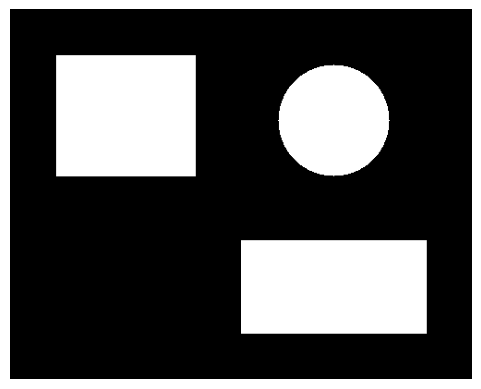

In [14]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

mask = np.zeros((400, 500), dtype=np.uint8)

cv2.rectangle(mask, (50, 50), (200, 180), 255, -1)
cv2.circle(mask, (350, 120), 60, 255, -1)
cv2.rectangle(mask, (250, 250), (450, 350), 255, -1)

save_path = "outputs/shape_and_contours/"

cv2.imwrite(save_path + "original_contours_mask.png", mask)

plt.imshow(mask, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

In [15]:
# Find Countours

contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print("NUmber of contours: ", len(contours))
print(hierarchy)

NUmber of contours:  3
[[[ 1 -1 -1 -1]
  [ 2  0 -1 -1]
  [-1  1 -1 -1]]]


New shape:  (400, 500, 3)


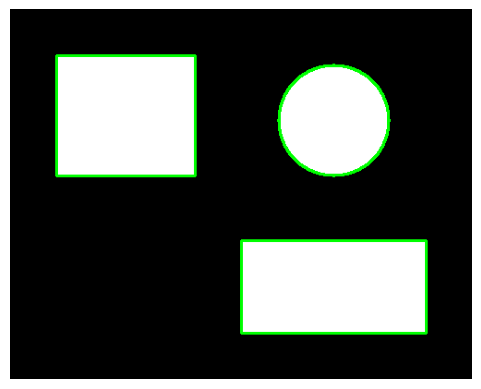

True

In [16]:
# Contours are usually drawn on a color image, not directly on the binary mask.

output = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
print("New shape: ", output.shape)

# cv2.drawContours(image, contours, contourIdx, color, thickness)
# contours   → list returned by findContours
# contourIdx → which contour to draw. -1 draws all of them
# color      → BGR color
# thickness  → line thickness in pixels. -1 fills the contour
cv2.drawContours(output, contours, -1, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB), vmin=0, vmax=255)
plt.axis("off")
plt.show()

cv2.imwrite(save_path + "drawn_contours.png", output)

In [17]:
# measurements
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    print(f"Contour {i}")
    print(" Area: ", area)
    print(" Perimeter: ", perimeter)

Contour 0
 Area:  20000.0
 Perimeter:  600.0
Contour 1
 Area:  11120.0
 Perimeter:  395.6467475891113
Contour 2
 Area:  19500.0
 Perimeter:  560.0


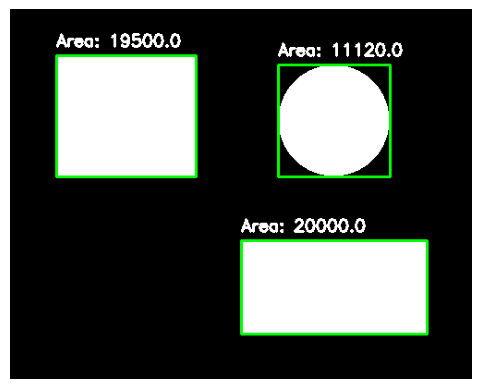

True

In [19]:
# Draw bounding rectangles
output = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

for cnt in contours:

    area = cv2.contourArea(cnt)
    if area > 500:
        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(output, f"Area: {area}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB), vmin=0, vmax=255)
plt.axis("off")
plt.show()
cv2.imwrite(save_path + "bounding_rectangles.png", output)

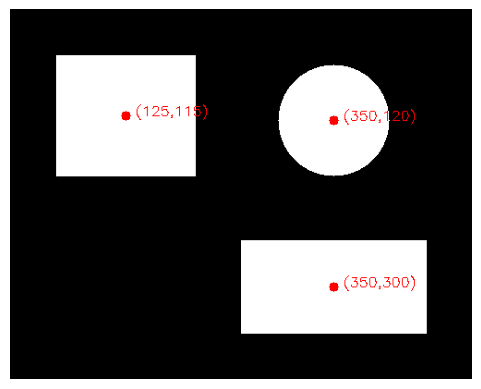

True

In [21]:
# Compute moments and centroids
output = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 500:
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.circle(output, (cx, cy), 5, (0, 0, 255), -1)
            cv2.putText(output, f"({cx},{cy})", (cx + 10, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB), vmin=0, vmax=255)
plt.axis("off")
plt.show()
cv2.imwrite(save_path + "centroids.png", output)


In [22]:
# Filtering by area
mask_noise = mask.copy()

cv2.circle(mask_noise, (20, 300), 4, 255, -1)
cv2.circle(mask_noise, (80, 350), 3, 255, -1)
cv2.circle(mask_noise, (480, 30), 5, 255, -1)

contours, _ = cv2.findContours(mask_noise, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = cv2.cvtColor(mask_noise, cv2.COLOR_GRAY2BGR)

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 500:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
    else:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 0, 255), 1)

cv2.imwrite(save_path + "filter_by_area.png", output)

True